# ViT Behavior Classifier Results Summary

This notebook loads saved artifacts from the completed classifier run so the
results can be reviewed and shared without rerunning training.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

In [2]:
RUNS_DIR = Path("artifacts/runs/cow-behavior-vit")
CV_DIR = RUNS_DIR / "cv"
FINAL_DIR = RUNS_DIR / "final"
FIGURES_DIR = Path("artifacts/figures/vit_classifier")
CV_FIGURES_DIR = FIGURES_DIR / "cv"


def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


for required_path in [
    CV_DIR / "fold_metrics.json",
    CV_DIR / "summary_metrics.json",
    FINAL_DIR / "held_out_test_metrics.json",
    FINAL_DIR / "held_out_test_classification_report.txt",
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Missing expected result file: {required_path}. Run the classifier first."
        )

## Cross-validation summary

In [3]:
cv_summary = pd.DataFrame(load_json(CV_DIR / "summary_metrics.json"))
cv_folds = pd.DataFrame(load_json(CV_DIR / "fold_metrics.json"))

display(cv_summary)
display(cv_folds)

accuracy_row = cv_summary.loc[cv_summary["metric"] == "accuracy"].iloc[0]
f1_row = cv_summary.loc[cv_summary["metric"] == "f1_weighted"].iloc[0]

display(
    Markdown(
        (
            f"5-fold CV was stable: mean accuracy was **{accuracy_row['mean']:.3%}** "
            f"(+/- **{accuracy_row['std']:.3%}**) and mean weighted F1 was "
            f"**{f1_row['mean']:.3%}** (+/- **{f1_row['std']:.3%}**)."
        )
    )
)

,metric,mean,std
0,accuracy,0.920131,0.009020
1,f1_weighted,0.919982,0.009025
2,train_runtime_sec,1276.507720,312.869305


,fold,train_samples,validation_samples,accuracy,f1_weighted,train_runtime_sec,train_steps_per_sec,train_samples_per_sec
0,1,17218,4305,0.923113,0.923082,1363.7174,3.952,126.258
1,2,17218,4305,0.929384,0.929205,1436.1283,3.753,119.892
2,3,17218,4305,0.923810,0.923622,1425.3314,3.782,120.800
3,4,17219,4304,0.918913,0.918728,1437.8778,3.749,119.753
4,5,17219,4304,0.905437,0.905275,719.4837,7.491,239.324


5-fold CV was stable: mean accuracy was **92.013%** (+/- **0.902%**) and mean weighted F1 was **91.998%** (+/- **0.902%**).

## Held-out test performance

In [4]:
test_metrics = load_json(FINAL_DIR / "held_out_test_metrics.json")
classification_report_text = (
    FINAL_DIR / "held_out_test_classification_report.txt"
).read_text(encoding="utf-8")

display(pd.DataFrame([test_metrics]))
display(Markdown("```text\n" + classification_report_text + "\n```"))

,accuracy,f1_weighted
0,0.928139,0.927884


```text
                precision    recall  f1-score   support

drinking water       0.95      0.97      0.96       112
      foraging       0.95      0.97      0.96       856
    lying down       0.89      0.86      0.87       678
    rumination       0.89      0.89      0.89       912
         stand       0.96      0.96      0.96      1241

      accuracy                           0.93      3799
     macro avg       0.93      0.93      0.93      3799
  weighted avg       0.93      0.93      0.93      3799

```

## Saved figures

### `cv_fold_metrics.png`

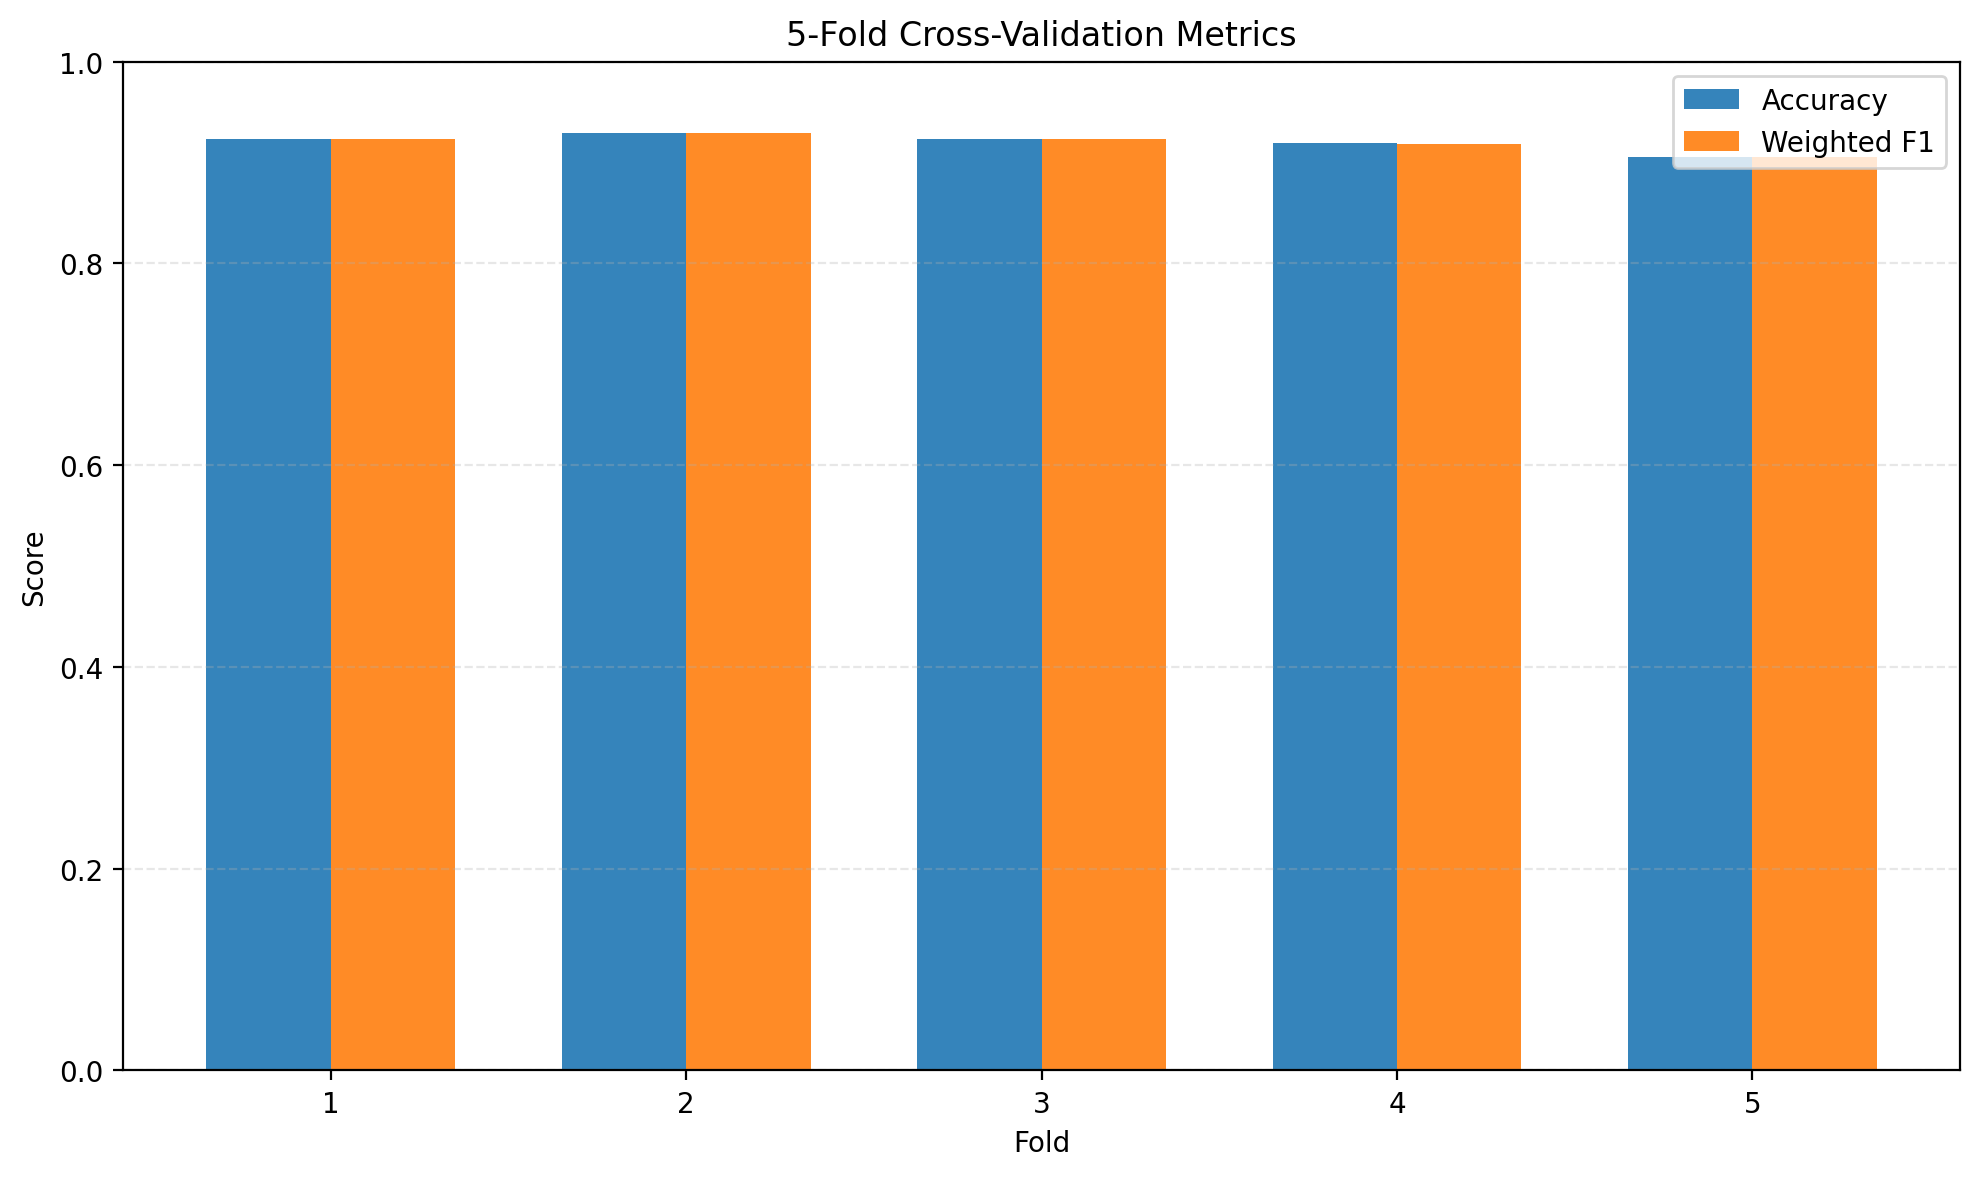

### `confusion_matrix.png`

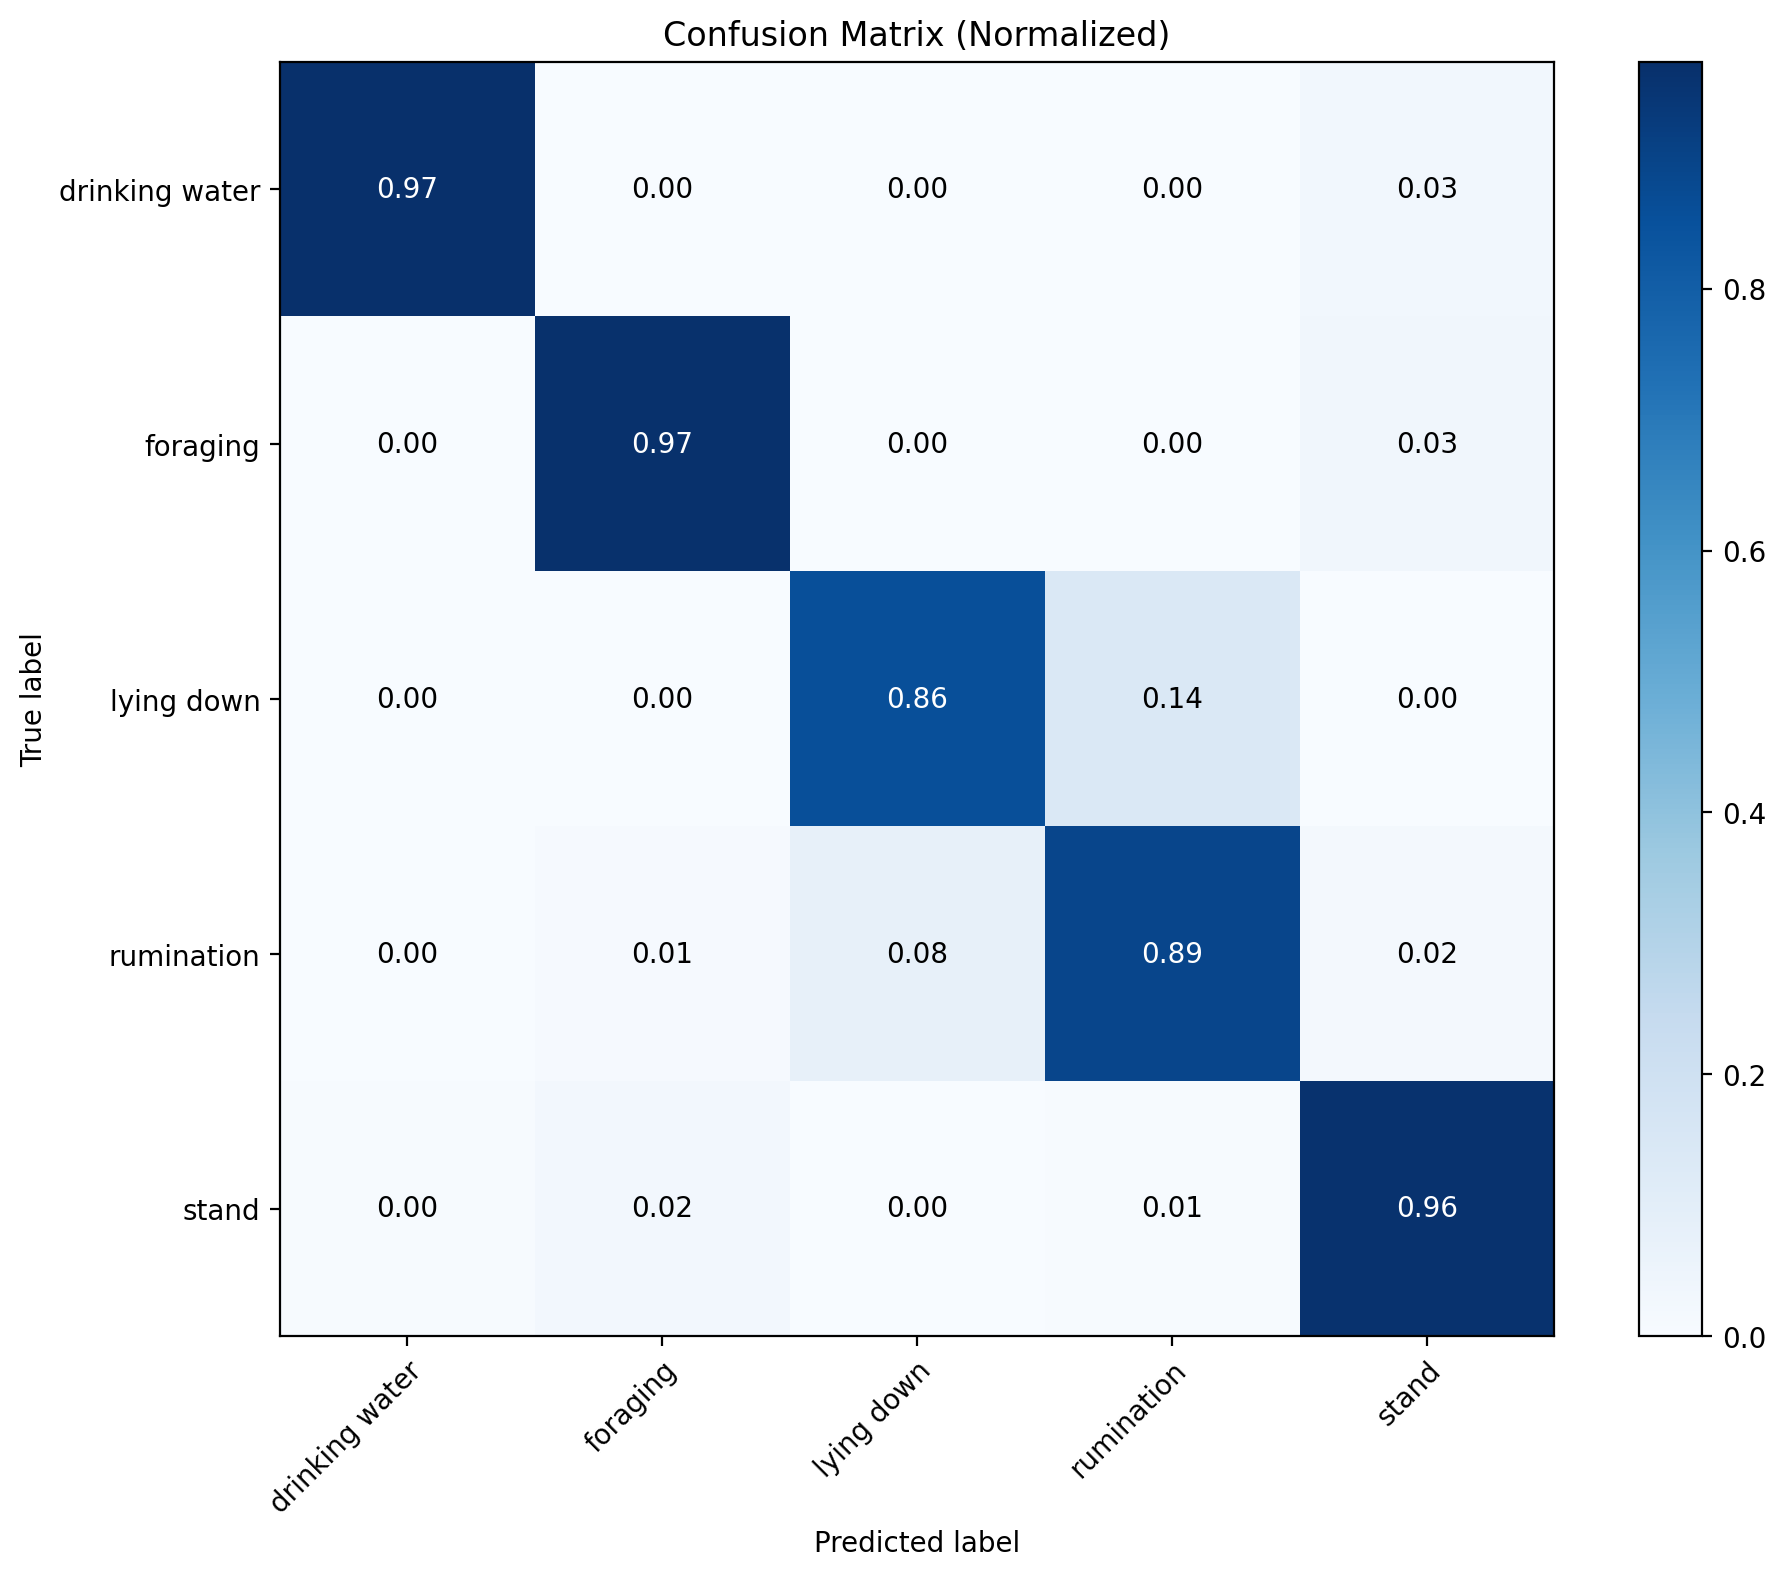

### `precision_recall_by_behavior.png`

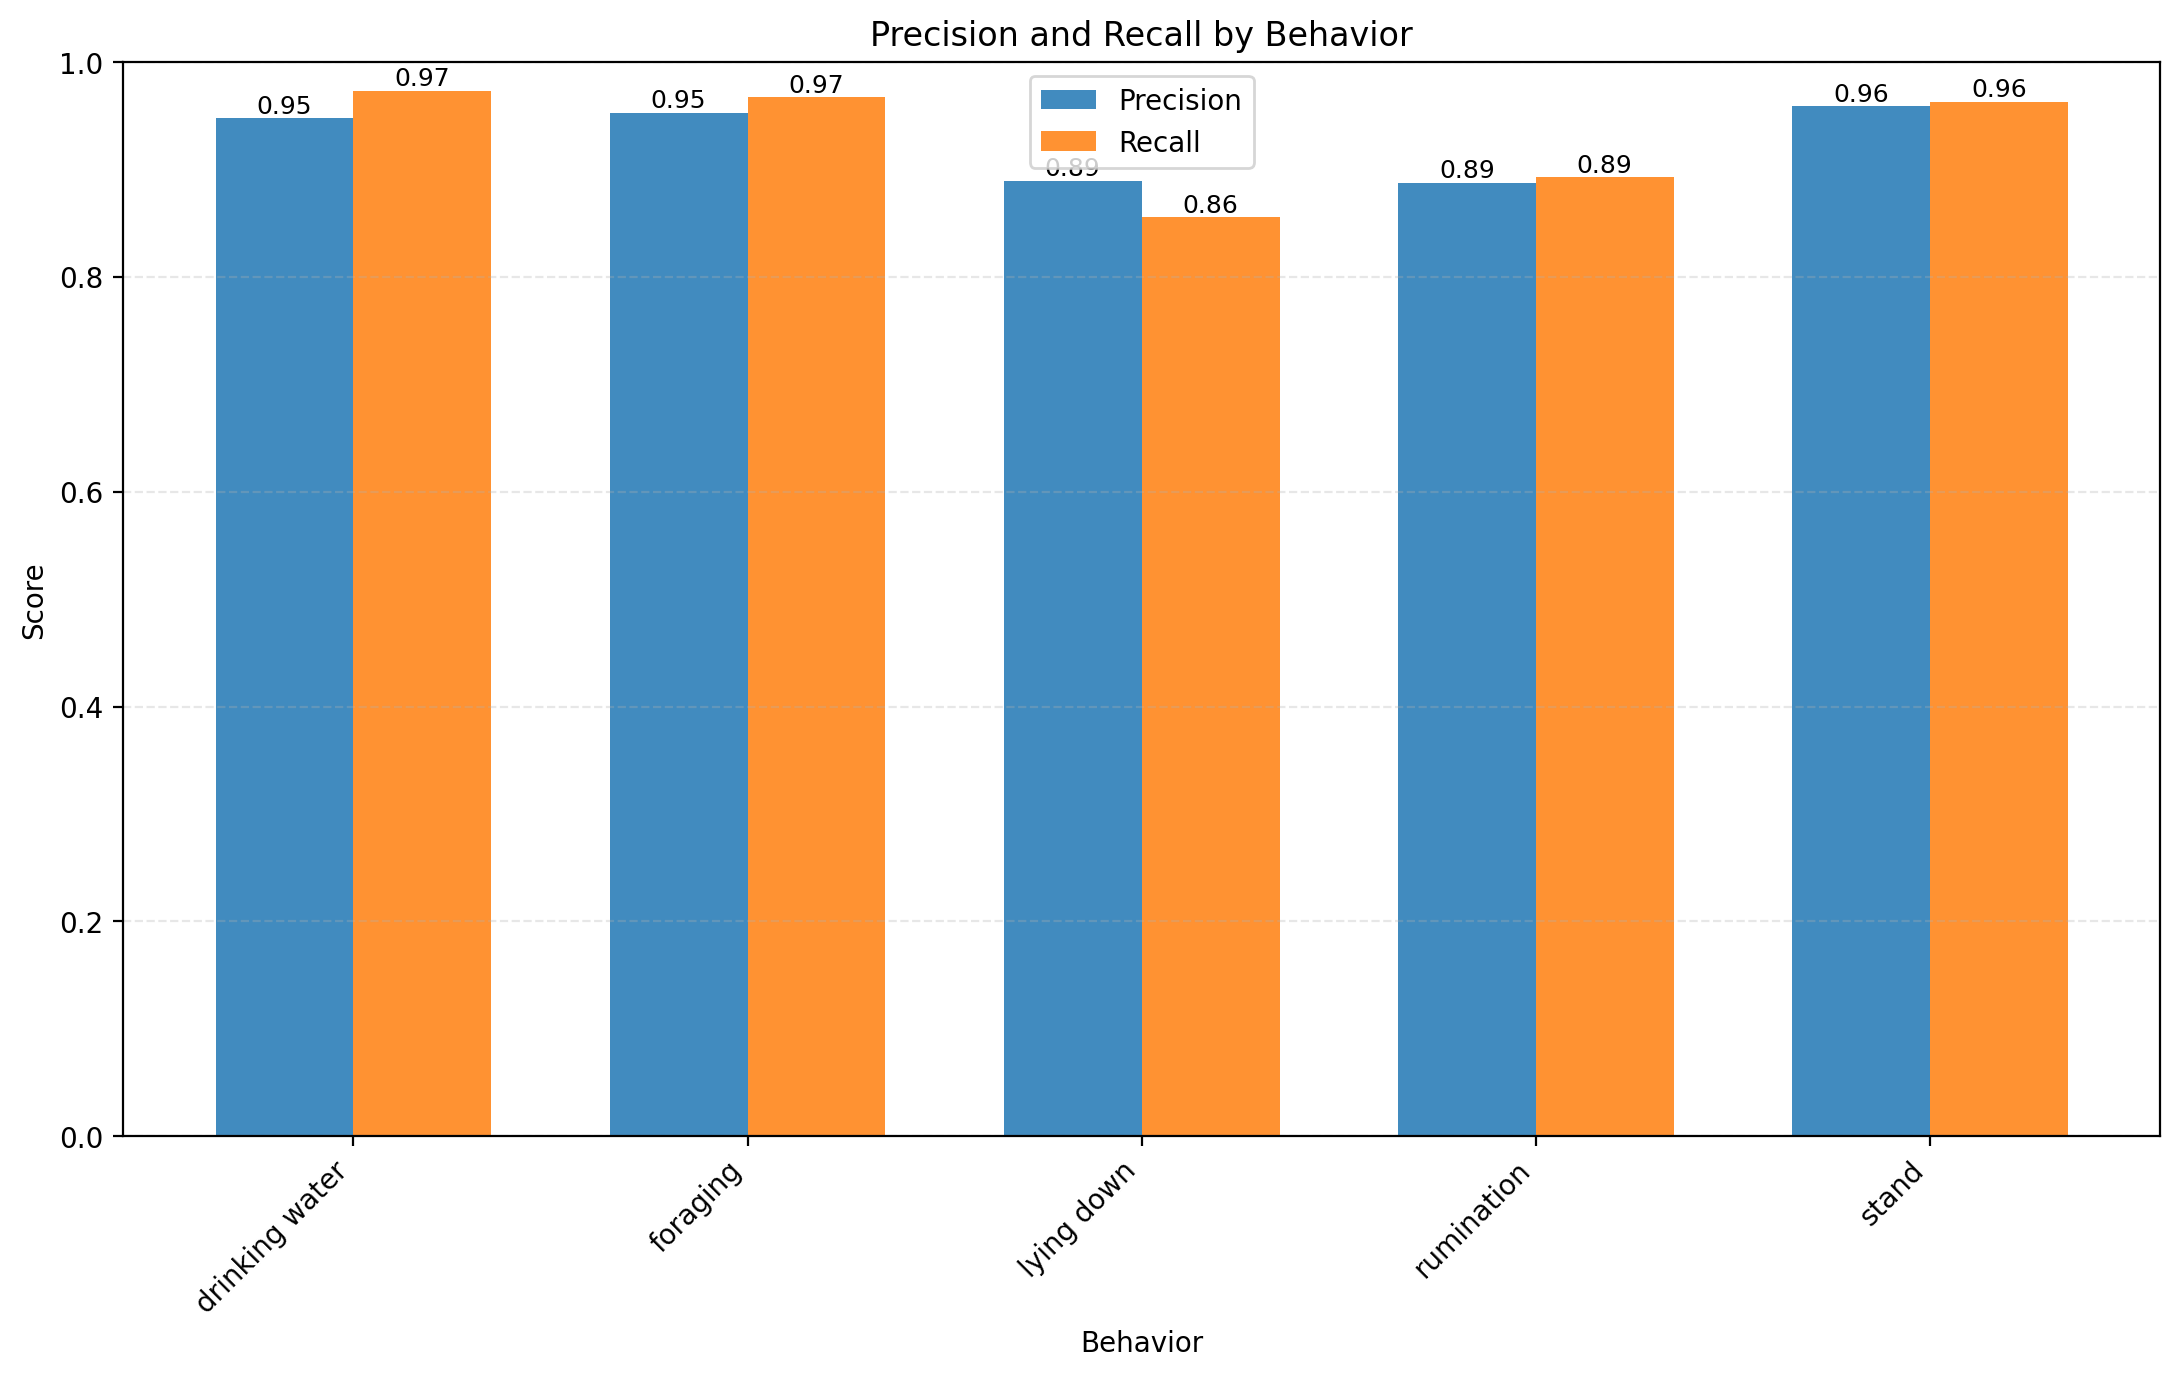

### `sample_predictions_grid.png`

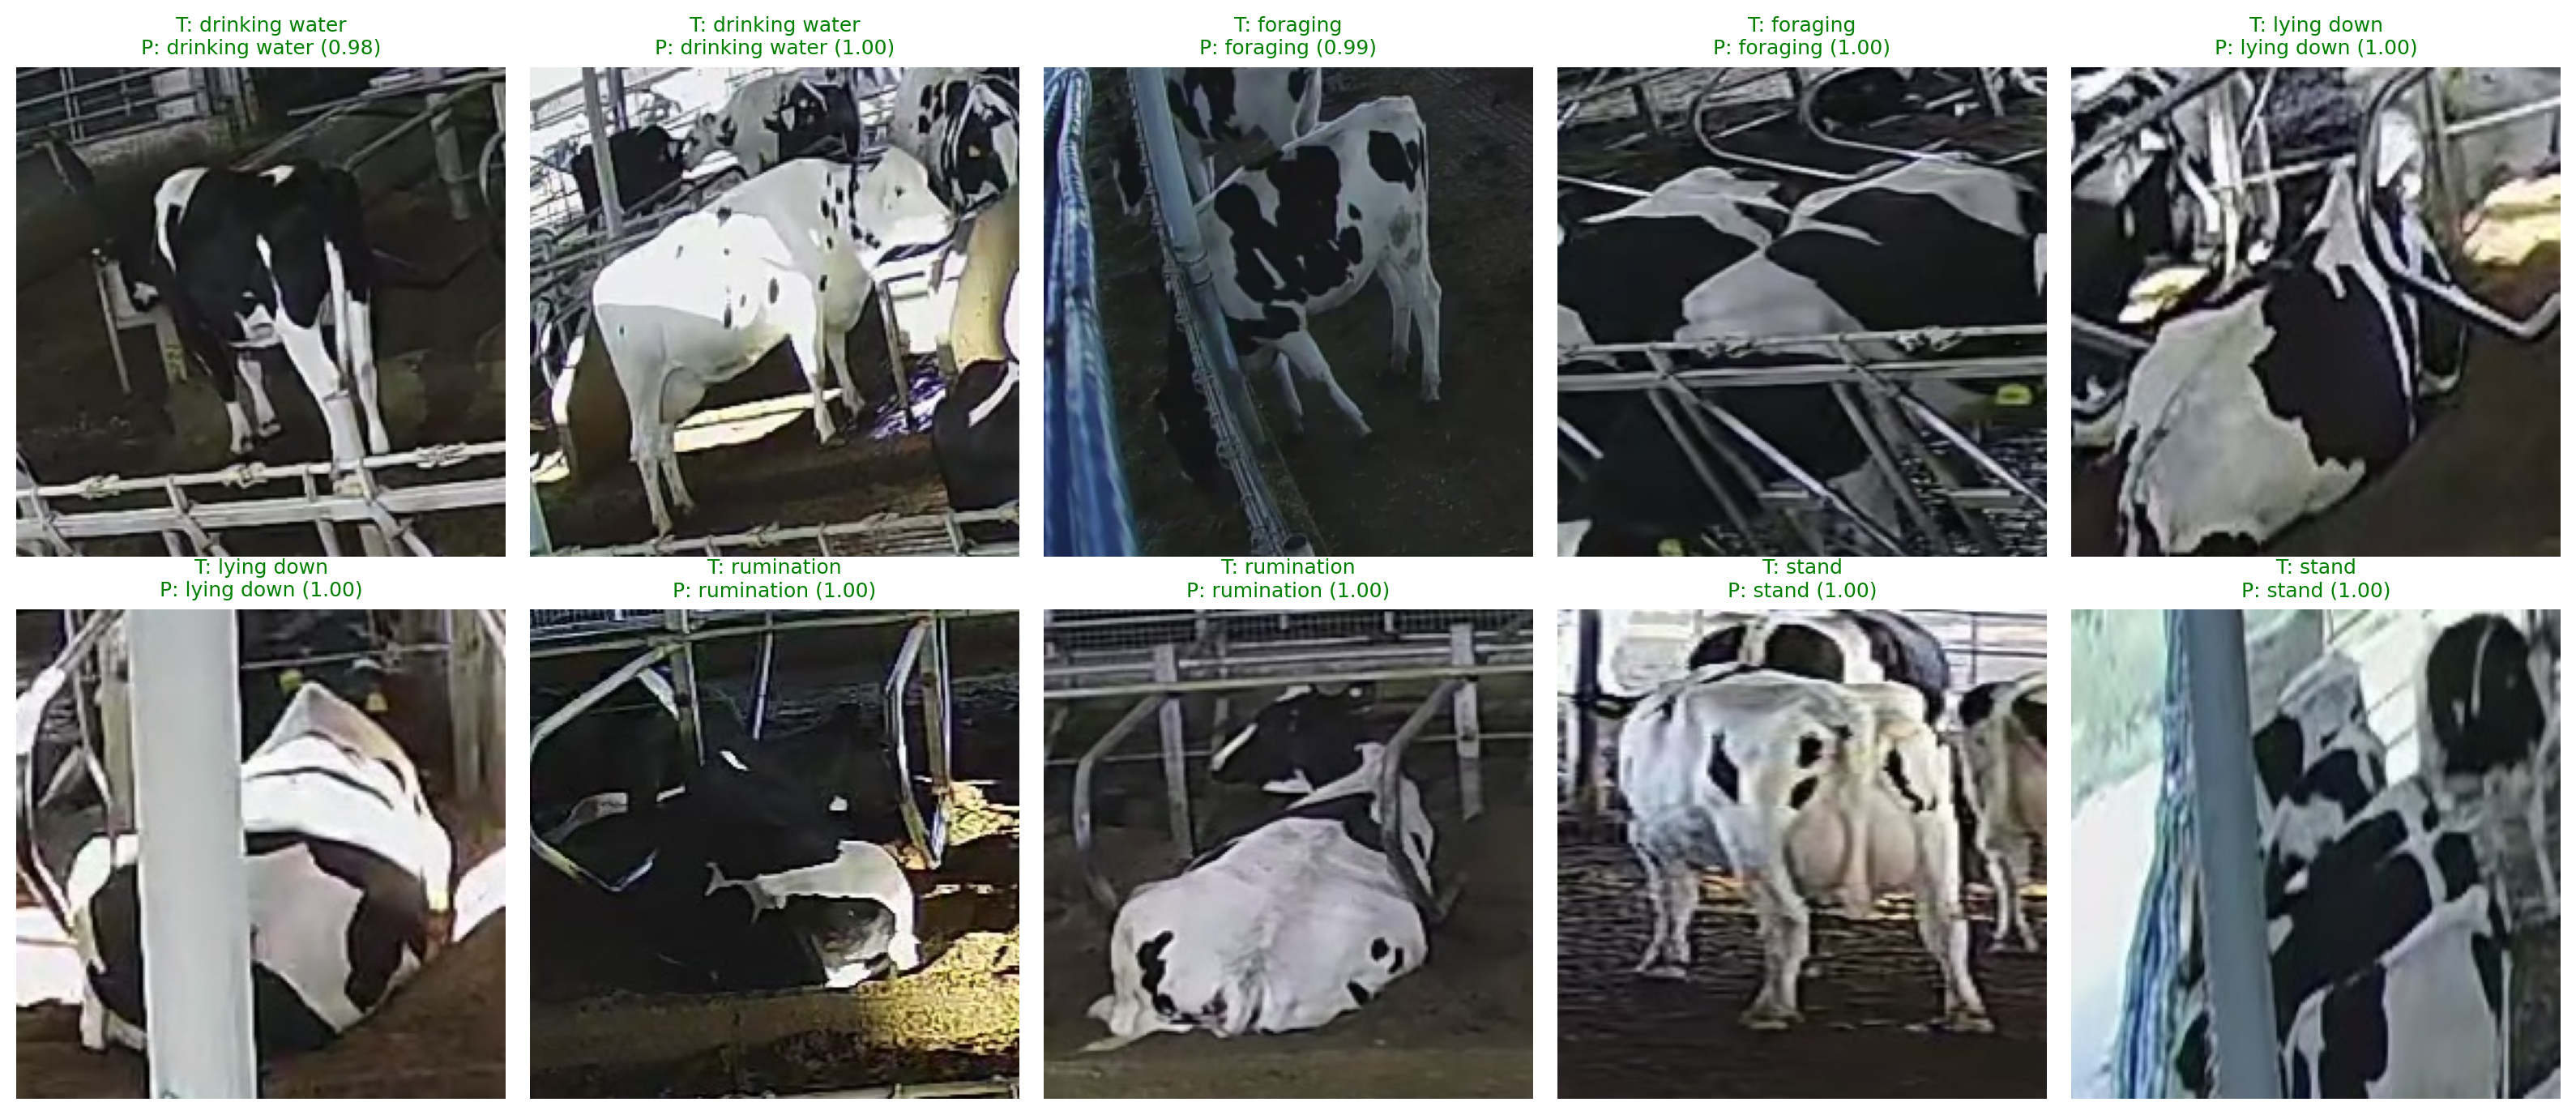

In [5]:
for image_path in [
    CV_FIGURES_DIR / "cv_fold_metrics.png",
    FIGURES_DIR / "confusion_matrix.png",
    FIGURES_DIR / "precision_recall_by_behavior.png",
    FIGURES_DIR / "sample_predictions_grid.png",
]:
    if image_path.exists():
        display(Markdown(f"### `{image_path.name}`"))
        display(Image(filename=str(image_path)))